# Predykcja płatności klientów – sklearn Pipeline

**Problem biznesowy:** Przewidujemy, które zamówienia zostaną zapłacone i jaka będzie wartość płatności.
Dzięki temu dział sprzedaży może priorytetyzować klientów wysokiego ryzyka.

**Podejście:**
1. EDA – zrozumienie danych
2. Feature engineering – tworzenie cech z sensem biznesowym
3. sklearn Pipeline – preprocessing + model w jednym obiekcie
4. Cross-validation – rzetelna ewaluacja (bez data leakage)
5. Feature importance – interpretacja modelu

## 1. Importy

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score, KFold, train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
plt.style.use('seaborn-v0_8-whitegrid')

## 2. Wczytanie i wstępna inspekcja danych

Zawsze zaczynamy od `.info()`, `.describe()` i sprawdzenia braków.
To podstawa dobrego EDA – bez tego nie wiemy co przetwarzać.

In [33]:
df = pd.read_csv('zamowienia_testowe.csv')

print(f"Wymiary datasetu: {df.shape}")
print(f"\nTypy kolumn:")
print(df.dtypes)
print(f"\nPierwsze 5 wierszy:")
df.head()

Wymiary datasetu: (150, 9)

Typy kolumn:
ID                       int64
Data zamowienia         object
Nazwa klienta           object
Sprzedawca              object
Branża                  object
Liczba produktow         int64
Wartosc jednostkowa    float64
Zapłacono              float64
Komentarz               object
dtype: object

Pierwsze 5 wierszy:


,ID,Data zamowienia,Nazwa klienta,Sprzedawca,Branża,Liczba produktow,Wartosc jednostkowa,Zapłacono,Komentarz
0,1001,2023-01-01,MedSupply,Anna Wiśniewska,Medycyna,39,325.48,17793.10,Pilne
1,1002,2023-01-04,LogiTrans,Anna Wiśniewska,Energia,29,170.89,5861.00,NaN
2,1003,2023-01-08,PrintMaster,Piotr Kowalczyk,IT / Technologia,15,264.11,5396.26,Klient VIP
3,1004,2023-01-11,Nowak Trading,Tomasz Nowak,Rolnictwo,43,455.63,17374.71,Pilne
4,1005,2023-01-15,LogiTrans,Anna Wiśniewska,Budownictwo,8,139.66,1539.99,NaN


In [34]:
# Braki danych – procent nullów w każdej kolumnie
missing = df.isnull().mean().sort_values(ascending=False) * 100
missing = missing[missing > 0]

if missing.empty:
    print("Brak wartości NULL w datasecie.")
else:
    print("Procent braków danych:")
    print(missing.round(2))

Procent braków danych:
Komentarz    41.33
dtype: float64


Statystyki zmiennej target 'Zapłacono':
count      150.000000
mean      7019.962600
std       6152.986265
min         50.000000
25%       2127.590000
50%       4847.585000
75%      10829.325000
max      26204.310000
Name: Zapłacono, dtype: float64


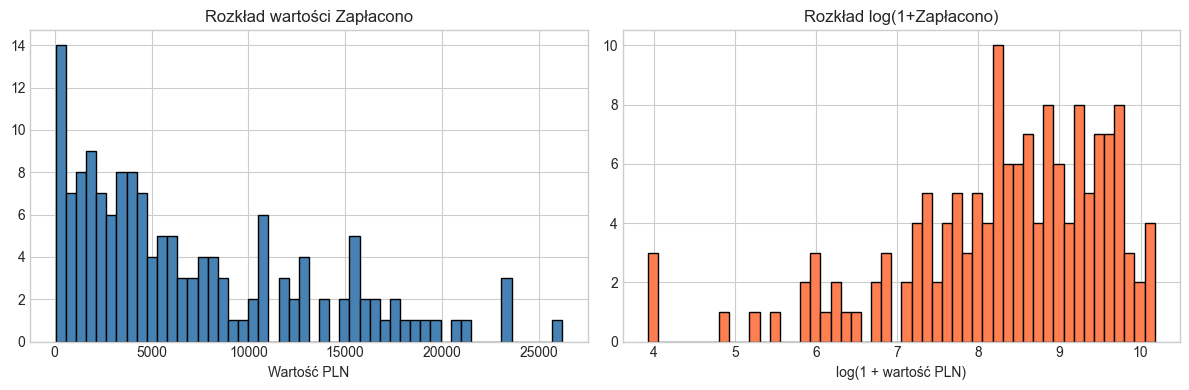

In [35]:
# Statystyki opisowe zmiennej target
df['Zapłacono'] = df['Zapłacono'].astype(str).str.replace(',', '.').astype(float)

print("Statystyki zmiennej target 'Zapłacono':")
print(df['Zapłacono'].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['Zapłacono'], bins=50, edgecolor='black', color='steelblue')
axes[0].set_title('Rozkład wartości Zapłacono')
axes[0].set_xlabel('Wartość PLN')

# Log-transform ujawnia ukrytą strukturę w danych skośnych
log_vals = np.log1p(df['Zapłacono'].clip(lower=0))
axes[1].hist(log_vals, bins=50, edgecolor='black', color='coral')
axes[1].set_title('Rozkład log(1+Zapłacono)')
axes[1].set_xlabel('log(1 + wartość PLN)')

plt.tight_layout()
plt.show()

## 3. Analiza korelacji

Przed modelowaniem sprawdzamy zależności między zmiennymi numerycznymi.

- **Silna korelacja cech z targetem** → potencjalnie wartościowe predyktory
- **Silna korelacja między cechami** → ryzyko multikolinearności (szczególnie dla modeli liniowych)
- **Heatmapa** daje szybki przegląd całej macierzy korelacji

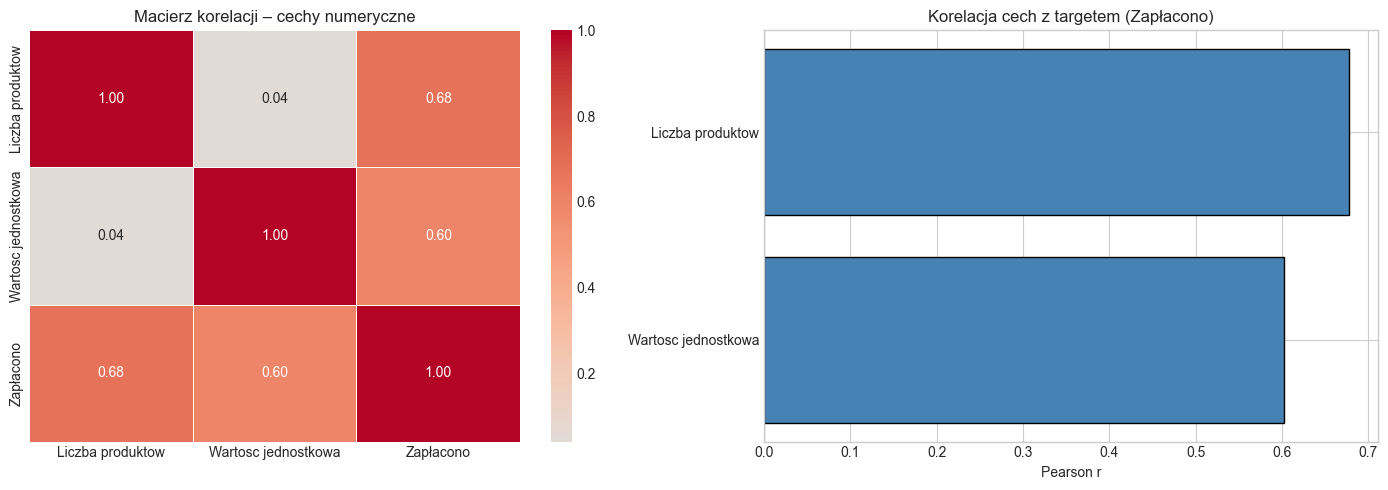


Najsilniej skorelowane z targetem:
Liczba produktow       0.677593
Wartosc jednostkowa    0.601694


In [36]:
num_df = df.select_dtypes(include='number').drop(columns=['ID'], errors='ignore')

corr_matrix = num_df.corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmapa całej macierzy korelacji
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f', cmap='coolwarm', center=0,
    linewidths=0.5, ax=axes[0]
)
axes[0].set_title('Macierz korelacji – cechy numeryczne')

# Korelacja cech z targetem (posortowana)
target_corr = corr_matrix['Zapłacono'].drop('Zapłacono').sort_values()
colors = ['coral' if v < 0 else 'steelblue' for v in target_corr]
axes[1].barh(target_corr.index, target_corr.values, color=colors, edgecolor='black')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Korelacja cech z targetem (Zapłacono)')
axes[1].set_xlabel('Pearson r')

plt.tight_layout()
plt.savefig('correlation.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nNajsilniej skorelowane z targetem:")
print(target_corr.abs().sort_values(ascending=False).to_string())

## 4. A/B Testing – analiza statystyczna grup

Przed budową modelu warto zweryfikować hipotezy biznesowe testem statystycznym.

**Pytanie:** Czy dwie wybrane branże różnią się istotnie statystycznie wartością płatności?

Używamy **Mann-Whitney U** zamiast t-testu, bo:
- Nie zakładamy normalności rozkładu (wartości sprzedaży są zazwyczaj skośne)
- Jest odporny na wartości odstające

Dodatkowo liczymy **Cohen's d** – wielkość efektu. Sama istotność statystyczna (p-value) bez wielkości efektu mówi mało: przy dużej próbie nawet trywialna różnica może być "istotna".

In [37]:
from scipy import stats

ALPHA = 0.05  # poziom istotności

# Wybierz dwie branże z największą liczbą rekordów (żeby test miał moc)
branza_col = 'Branża' if 'Branża' in df.columns else 'Branza'
top_branże = df[branza_col].value_counts().head(2).index.tolist()
group_a_name, group_b_name = top_branże[0], top_branże[1]

group_a = df[df[branza_col] == group_a_name]['Zapłacono'].dropna()
group_b = df[df[branza_col] == group_b_name]['Zapłacono'].dropna()

print(f"Grupa A: {group_a_name} (n={len(group_a)})")
print(f"  Mediana: {group_a.median():.2f} PLN  |  Mean: {group_a.mean():.2f} PLN  |  Std: {group_a.std():.2f}")
print(f"\nGrupa B: {group_b_name} (n={len(group_b)})")
print(f"  Mediana: {group_b.median():.2f} PLN  |  Mean: {group_b.mean():.2f} PLN  |  Std: {group_b.std():.2f}")

# --- Test Shapiro-Wilk: czy rozkłady są normalne? ---
_, p_norm_a = stats.shapiro(group_a)
_, p_norm_b = stats.shapiro(group_b)
print(f"\nTest normalności Shapiro-Wilk:")
print(f"  {group_a_name}: p={p_norm_a:.4f} → {'normalny' if p_norm_a > ALPHA else 'NIEnormalny'}")
print(f"  {group_b_name}: p={p_norm_b:.4f} → {'normalny' if p_norm_b > ALPHA else 'NIEnormalny'}")

Grupa A: Edukacja (n=26)
  Mediana: 3976.91 PLN  |  Mean: 4724.28 PLN  |  Std: 4182.36

Grupa B: IT / Technologia (n=18)
  Mediana: 8210.42 PLN  |  Mean: 9652.39 PLN  |  Std: 6663.32

Test normalności Shapiro-Wilk:
  Edukacja: p=0.0070 → NIEnormalny
  IT / Technologia: p=0.0568 → normalny


In [38]:
# --- Mann-Whitney U test ---
stat_mw, p_mw = stats.mannwhitneyu(group_a, group_b, alternative='two-sided')

# --- Cohen's d – wielkość efektu ---
pooled_std = np.sqrt((group_a.std()**2 + group_b.std()**2) / 2)
cohens_d = (group_a.mean() - group_b.mean()) / pooled_std

def interpret_cohens_d(d):
    d = abs(d)
    if d < 0.2:   return "znikomy"
    elif d < 0.5: return "mały"
    elif d < 0.8: return "średni"
    else:          return "duży"

print("=" * 55)
print("WYNIKI TESTU A/B")
print("=" * 55)
print(f"H0: mediany grup są równe")
print(f"H1: mediany grup są różne")
print(f"\nTest Mann-Whitney U:")
print(f"  statystyka U = {stat_mw:.2f}")
print(f"  p-value      = {p_mw:.4f}")
print(f"\nWniosek (α={ALPHA}):")
if p_mw < ALPHA:
    print(f"  Odrzucamy H0 – różnica jest ISTOTNA statystycznie.")
else:
    print(f"  Brak podstaw do odrzucenia H0 – różnica NIE jest istotna.")
print(f"\nCohen's d = {cohens_d:.3f} → efekt {interpret_cohens_d(cohens_d)}")
print("=" * 55)

WYNIKI TESTU A/B
H0: mediany grup są równe
H1: mediany grup są różne

Test Mann-Whitney U:
  statystyka U = 116.00
  p-value      = 0.0050

Wniosek (α=0.05):
  Odrzucamy H0 – różnica jest ISTOTNA statystycznie.

Cohen's d = -0.886 → efekt duży


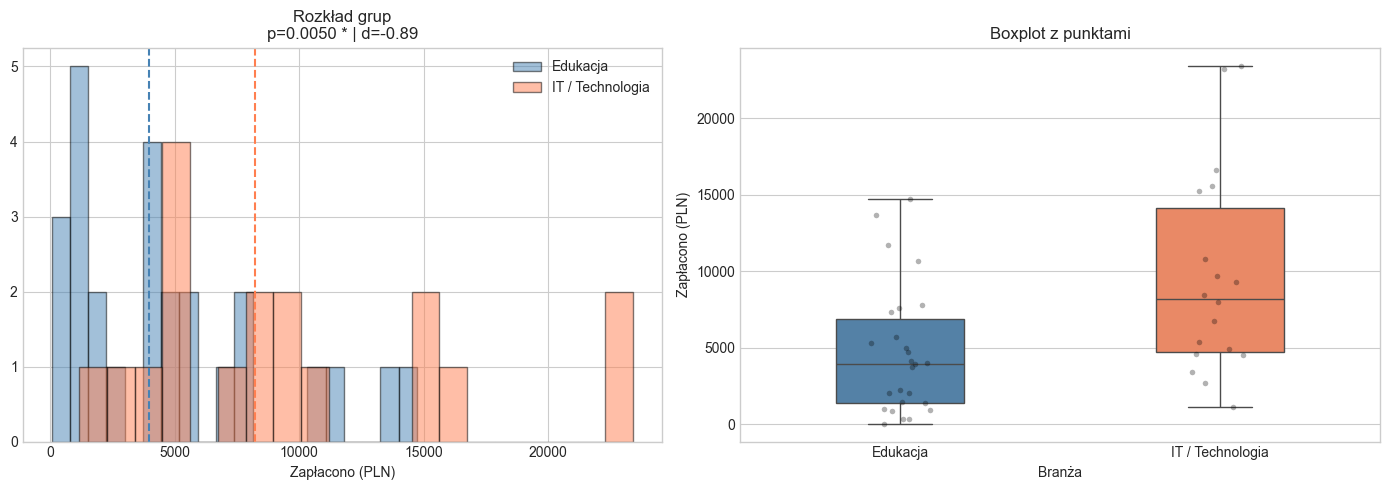

In [39]:
# Wizualizacja: rozkłady obu grup + mediana
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram z KDE
for group, name, color in [(group_a, group_a_name, 'steelblue'), (group_b, group_b_name, 'coral')]:
    axes[0].hist(group, bins=20, alpha=0.5, color=color, edgecolor='black', label=name)
    axes[0].axvline(group.median(), color=color, linestyle='--', linewidth=1.5)

axes[0].set_title('Rozkład wartości płatności – porównanie grup')
axes[0].set_xlabel('Zapłacono (PLN)')
axes[0].legend()
sig_label = f'p={p_mw:.4f} {"*" if p_mw < ALPHA else "ns"} | d={cohens_d:.2f}'
axes[0].set_title(f'Rozkład grup\n{sig_label}')

# Boxplot z punktami (stripplot)
plot_df = pd.DataFrame({
    'Wartość': pd.concat([group_a, group_b]).values,
    'Branża': [group_a_name] * len(group_a) + [group_b_name] * len(group_b)
})
sns.boxplot(data=plot_df, x='Branża', y='Wartość', palette=['steelblue', 'coral'],
            width=0.4, ax=axes[1])
sns.stripplot(data=plot_df, x='Branża', y='Wartość', color='black',
              alpha=0.3, size=4, ax=axes[1])
axes[1].set_title('Boxplot z punktami')
axes[1].set_ylabel('Zapłacono (PLN)')

plt.tight_layout()
plt.savefig('ab_test.png', dpi=100, bbox_inches='tight')
plt.show()

## 3. Feature Engineering

Feature engineering to miejsce, gdzie wkładamy **wiedzę domenową** w model.
AutoML tego nie robi – to właśnie odróżnia dobrego DS od sklecenia `compare_models()`.

In [40]:
df_model = df.copy()

# Usuń kolumny-identyfikatory (nie wnoszą informacji predykcyjnej)
cols_to_drop = ['ID', 'Komentarz']
df_model.drop(columns=[c for c in cols_to_drop if c in df_model.columns], inplace=True)

# --- Cechy z dat (jeśli istnieją kolumny z datą) ---
date_cols = [c for c in df_model.columns if 'data' in c.lower() or 'date' in c.lower()]
for col in date_cols:
    try:
        df_model[col] = pd.to_datetime(df_model[col])
        df_model[f'{col}_miesiac'] = df_model[col].dt.month
        df_model[f'{col}_dzien_tygodnia'] = df_model[col].dt.dayofweek
        df_model[f'{col}_kwartal'] = df_model[col].dt.quarter
        df_model.drop(columns=[col], inplace=True)
        print(f"Stworzono cechy z kolumny dat: {col}")
    except Exception:
        pass

print(f"\nKolumny po feature engineering: {list(df_model.columns)}")
print(f"Wymiary: {df_model.shape}")

Stworzono cechy z kolumny dat: Data zamowienia

Kolumny po feature engineering: ['Nazwa klienta', 'Sprzedawca', 'Branża', 'Liczba produktow', 'Wartosc jednostkowa', 'Zapłacono', 'Data zamowienia_miesiac', 'Data zamowienia_dzien_tygodnia', 'Data zamowienia_kwartal']
Wymiary: (150, 9)


## 4. Podział na cechy i target

Separujemy X (cechy wejściowe) od y (to co chcemy przewidzieć).
Następnie dzielimy dane: **80% trening, 20% test** – test set zostaje zablokowany do końca.

In [41]:
TARGET = 'Zapłacono'

X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# Automatyczny podział kolumn na numeryczne i kategoryczne
num_cols = X.select_dtypes(include=['number']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Kolumny numeryczne ({len(num_cols)}): {num_cols}")
print(f"Kolumny kategoryczne ({len(cat_cols)}): {cat_cols}")

Train: (120, 8), Test: (30, 8)
Kolumny numeryczne (5): ['Liczba produktow', 'Wartosc jednostkowa', 'Data zamowienia_miesiac', 'Data zamowienia_dzien_tygodnia', 'Data zamowienia_kwartal']
Kolumny kategoryczne (3): ['Nazwa klienta', 'Sprzedawca', 'Branża']


## 5. sklearn Pipeline – preprocessing + model

**Pipeline** to kluczowy pattern w produkcyjnym ML.

Dlaczego pipeline zamiast ręcznych transformacji?
- **Brak data leakage** – scaler uczy się tylko na danych treningowych
- **Jeden obiekt do deploymentu** – `pipeline.predict(X_new)` robi wszystko
- **Łatwy cross-validation** – CV wie jak przetworzyć każdy fold oddzielnie

`ColumnTransformer` pozwala zastosować różne transformacje do różnych kolumn jednocześnie.

In [42]:
# Preprocessing dla kolumn numerycznych: uzupełnij braki medianą, standaryzuj
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Preprocessing dla kolumn kategorycznych: uzupełnij braków jako 'missing', one-hot encode
cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
], remainder='drop')

# Porównujemy 3 modele – od prostego do złożonego
models = {
    'Ridge (baseline)': Ridge(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=RANDOM_STATE)
}

print("Ewaluacja modeli (5-fold CV na zbiorze treningowym):")
print(f"{'Model':<25} {'MAE (mean)':>12} {'MAE (std)':>10} {'R2 (mean)':>10}")
print("-" * 60)

results = {}
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    mae_scores = -cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='neg_mean_absolute_error')
    r2_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='r2')
    
    results[name] = {'mae_mean': mae_scores.mean(), 'mae_std': mae_scores.std(), 'r2_mean': r2_scores.mean()}
    print(f"{name:<25} {mae_scores.mean():>12.2f} {mae_scores.std():>10.2f} {r2_scores.mean():>10.3f}")

Ewaluacja modeli (5-fold CV na zbiorze treningowym):
Model                       MAE (mean)  MAE (std)  R2 (mean)
------------------------------------------------------------
Ridge (baseline)               2159.96     302.67      0.761
Random Forest                  1472.38     177.33      0.880
Gradient Boosting              1157.87     129.24      0.918


## 6. Finalny model – ewaluacja na zbiorze testowym

Wybieramy najlepszy model (najniższy MAE z CV) i trenujemy go na **całym** zbiorze treningowym.
Dopiero teraz patrzymy na zbiór testowy – raz, na koniec. To jest właściwy sposób.

In [43]:
best_name = min(results, key=lambda k: results[k]['mae_mean'])
print(f"Najlepszy model wg MAE z cross-validation: {best_name}")

best_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', models[best_name])
])

best_pipeline.fit(X_train, y_train)
y_pred = best_pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\n--- Wyniki na zbiorze testowym (hold-out) ---")
print(f"MAE  (Mean Absolute Error): {mae:.2f} PLN")
print(f"RMSE (Root Mean Sq Error):  {rmse:.2f} PLN")
print(f"R²   (Wariancja wyjaśniona): {r2:.3f}")
print(f"\nInterpretacja: Model myli się średnio o {mae:.2f} PLN na zamówieniu.")

Najlepszy model wg MAE z cross-validation: Gradient Boosting

--- Wyniki na zbiorze testowym (hold-out) ---
MAE  (Mean Absolute Error): 1301.65 PLN
RMSE (Root Mean Sq Error):  1963.11 PLN
R²   (Wariancja wyjaśniona): 0.910

Interpretacja: Model myli się średnio o 1301.65 PLN na zamówieniu.


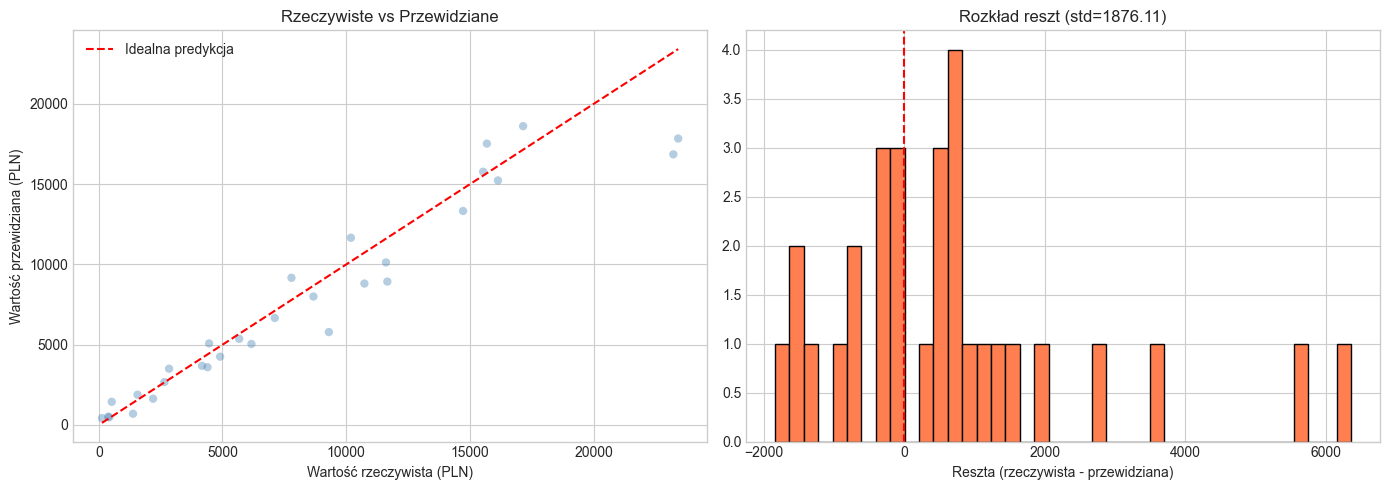

In [44]:
# Wykres: Prawdziwe vs Przewidziane wartości + rozkład reszt
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: predicted vs actual
axes[0].scatter(y_test, y_pred, alpha=0.4, edgecolors='none', color='steelblue')
min_val, max_val = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Idealna predykcja')
axes[0].set_xlabel('Wartość rzeczywista (PLN)')
axes[0].set_ylabel('Wartość przewidziana (PLN)')
axes[0].set_title('Rzeczywiste vs Przewidziane')
axes[0].legend()

# Histogram reszt
axes[1].hist(residuals, bins=40, edgecolor='black', color='coral')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Reszta (rzeczywista - przewidziana)')
axes[1].set_title(f'Rozkład reszt (std={residuals.std():.2f})')

plt.tight_layout()
plt.savefig('residuals_plot.png', dpi=100, bbox_inches='tight')
plt.show()

## 7. Feature Importance

Które cechy model uznaje za najważniejsze?
To kluczowe dla DS – rozumiesz model i możesz go uzasadnić biznesowo.

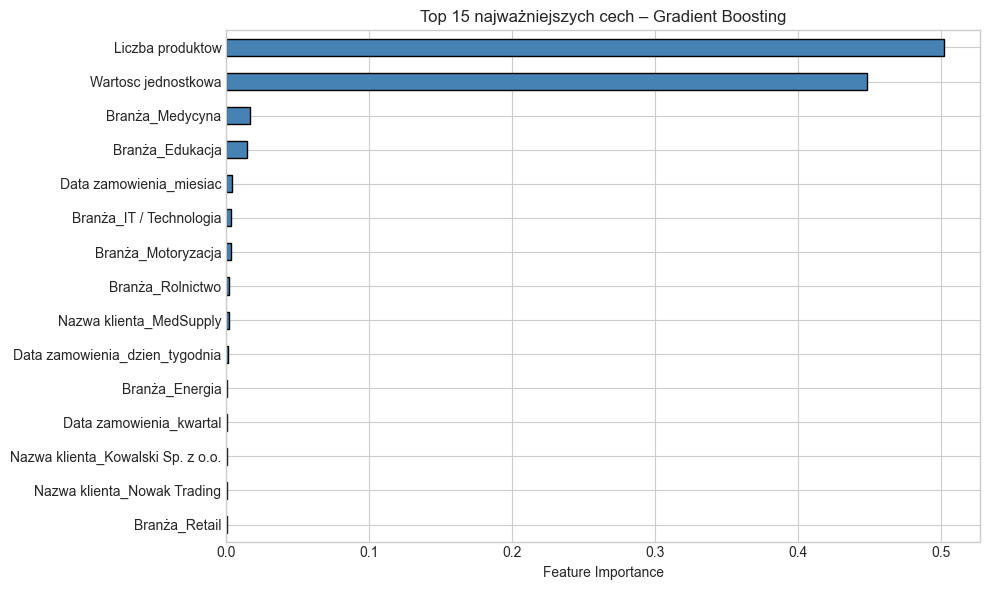

In [45]:
final_model = best_pipeline.named_steps['model']

if hasattr(final_model, 'feature_importances_'):
    # Pobierz nazwy cech po transformacji
    ohe = best_pipeline.named_steps['preprocessor'].named_transformers_.get('cat')
    if ohe and cat_cols:
        cat_feature_names = best_pipeline.named_steps['preprocessor'] \
            .named_transformers_['cat'] \
            .named_steps['encoder'] \
            .get_feature_names_out(cat_cols).tolist()
    else:
        cat_feature_names = []
    
    feature_names = num_cols + cat_feature_names
    importances = pd.Series(final_model.feature_importances_, index=feature_names)
    top_features = importances.sort_values(ascending=False).head(15)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    top_features.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(f'Top 15 najważniejszych cech – {best_name}')
    ax.set_xlabel('Feature Importance')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=100, bbox_inches='tight')
    plt.show()
else:
    print(f"Model {best_name} nie wspiera feature_importances_. Użyj modelu drzewiastego.")

## 8. SHAP – interpretacja modelu

**Feature Importance** mówi które cechy są globalnie ważne – ale nie mówi *jak* wpływają na predykcję.
**SHAP (SHapley Additive exPlanations)** rozwiązuje oba problemy:

- **Beeswarm plot** – dla każdej cechy widać kierunek i siłę wpływu na każdy rekord
- **Waterfall plot** – wyjaśnienie pojedynczej predykcji krok po kroku

SHAP to standard w produkcyjnym DS – używany w Allegro, Booking, Spotify do audytu modeli.

In [46]:
import shap

# Pobierz nazwy cech po transformacji (te same co w Feature Importance)
if cat_cols:
    cat_feature_names = best_pipeline.named_steps['preprocessor'] \
        .named_transformers_['cat'] \
        .named_steps['encoder'] \
        .get_feature_names_out(cat_cols).tolist()
else:
    cat_feature_names = []

feature_names = num_cols + cat_feature_names

# Przekształć X_test przez preprocessor – SHAP operuje na gotowych macierzach numerycznych
X_test_transformed = best_pipeline.named_steps['preprocessor'].transform(X_test)

# TreeExplainer – dedykowany dla modeli drzewiastych, szybki i dokładny
explainer = shap.TreeExplainer(best_pipeline.named_steps['model'])
shap_values = explainer(X_test_transformed)

# Nadaj nazwy cechom w obiekcie SHAP
shap_values.feature_names = feature_names

print(f"SHAP values obliczone dla {X_test_transformed.shape[0]} próbek i {X_test_transformed.shape[1]} cech.")

SHAP values obliczone dla 30 próbek i 35 cech.


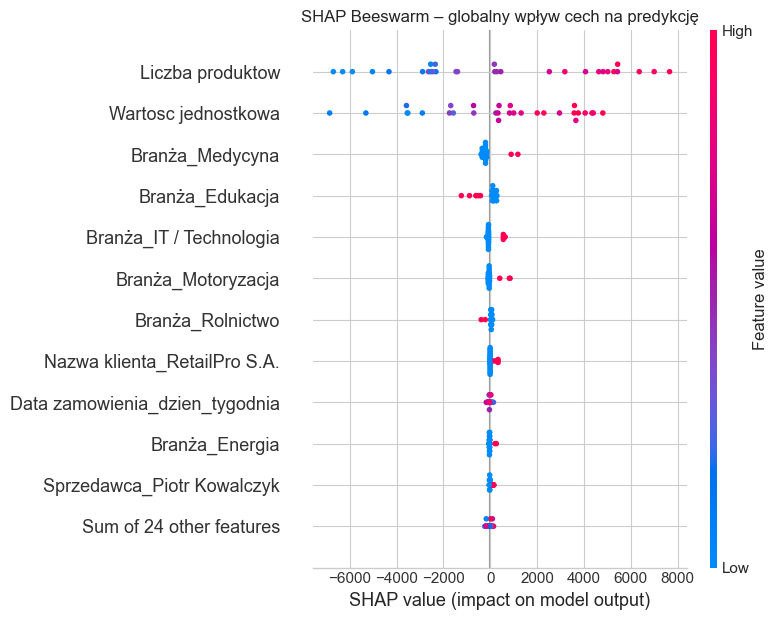

In [47]:
# Beeswarm plot – globalny widok: które cechy i jak wpływają na predykcje
# Każda kropka = jeden rekord z test setu
# Kolor: czerwony = wysoka wartość cechy, niebieski = niska
# Pozycja X: wpływ na predykcję (w lewo = obniża, w prawo = podwyższa)
fig, ax = plt.subplots(figsize=(10, 7))
shap.plots.beeswarm(shap_values, max_display=12, show=False)
plt.title("SHAP Beeswarm – globalny wpływ cech na predykcję")
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=100, bbox_inches='tight')
plt.show()

Wyjaśnienie predykcji dla próbki #0
  Rzeczywista wartość:   15536.37 PLN
  Przewidziana wartość:  15777.84 PLN


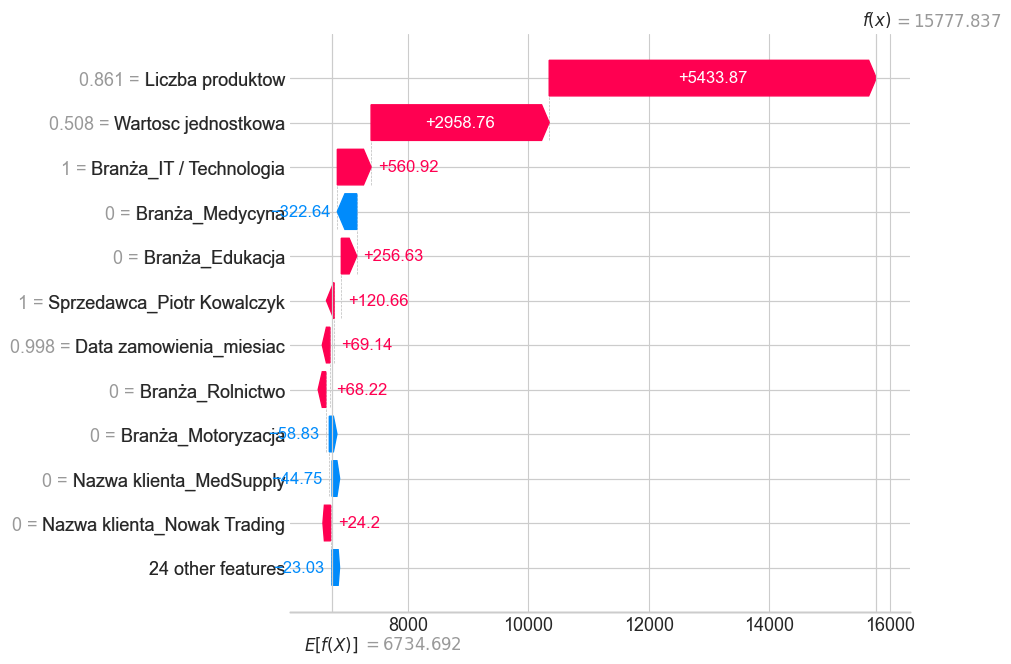

In [48]:
# Waterfall plot – wyjaśnienie jednej konkretnej predykcji
# Pokazuje jak model "doszedł" do wyniku: od wartości bazowej (E[f(X)])
# do finalnej predykcji, krok po kroku przez każdą cechę
sample_idx = 0
print(f"Wyjaśnienie predykcji dla próbki #{sample_idx}")
print(f"  Rzeczywista wartość:   {y_test.iloc[sample_idx]:.2f} PLN")
print(f"  Przewidziana wartość:  {best_pipeline.predict(X_test.iloc[[sample_idx]])[0]:.2f} PLN")

shap.plots.waterfall(shap_values[sample_idx], max_display=12, show=True)

## 8. Predykcje i zapis wyników

Generujemy predykcje na całym datasecie i zapisujemy z metadanymi:
- `prediction_label` – 1 jeśli przewidywana wartość > mediany ("zapłaci"), 0 jeśli nie
- `prediction_score` – dokładna przewidziana wartość PLN

In [49]:
X_all = df_model.drop(columns=[TARGET])
y_all = df_model[TARGET]

predictions_all = best_pipeline.predict(X_all)

# Retrain na całości danych (po finalnej ewaluacji)
best_pipeline.fit(X_all, y_all)

output_df = df.copy()
output_df['prediction_score'] = predictions_all.round(2)

median_threshold = np.median(predictions_all)
output_df['prediction_label'] = (predictions_all > median_threshold).astype(int)

output_df.to_csv('predykcje.csv', index=False)

print(f"Zapisano predykcje do 'predykcje.csv'")
print(f"Threshold (mediana): {median_threshold:.2f} PLN")
print(f"Przewidziane jako zapłacone (1): {output_df['prediction_label'].sum()}")
print(f"Przewidziane jako niezapłacone (0): {(output_df['prediction_label']==0).sum()}")
output_df.head()

Zapisano predykcje do 'predykcje.csv'
Threshold (mediana): 4867.40 PLN
Przewidziane jako zapłacone (1): 75
Przewidziane jako niezapłacone (0): 75


,ID,Data zamowienia,Nazwa klienta,Sprzedawca,Branża,Liczba produktow,Wartosc jednostkowa,Zapłacono,Komentarz,prediction_score,prediction_label
0,1001,2023-01-01,MedSupply,Anna Wiśniewska,Medycyna,39,325.48,17793.10,Pilne,17650.45,1
1,1002,2023-01-04,LogiTrans,Anna Wiśniewska,Energia,29,170.89,5861.00,NaN,5732.12,1
2,1003,2023-01-08,PrintMaster,Piotr Kowalczyk,IT / Technologia,15,264.11,5396.26,Klient VIP,5227.25,1
3,1004,2023-01-11,Nowak Trading,Tomasz Nowak,Rolnictwo,43,455.63,17374.71,Pilne,17263.18,1
4,1005,2023-01-15,LogiTrans,Anna Wiśniewska,Budownictwo,8,139.66,1539.99,NaN,1634.73,0


## 9. Zapis modelu

Zapisujemy cały pipeline (preprocessing + model) jako jeden plik.
Dzięki temu `app.py` może załadować model i robić predykcje bez żadnych dodatkowych kroków.

## 10. MLflow – śledzenie eksperymentów

**MLflow** to standard w produkcyjnym ML do logowania:
- parametrów modelu (hiperparametry)
- metryk (MAE, RMSE, R²)
- artefaktów (wykresy, model)

Dzięki temu każdy run jest powtarzalny i porównywalny. Uruchom `mlflow ui` w terminalu żeby zobaczyć dashboard z historią eksperymentów.

In [ ]:
import mlflow
import mlflow.sklearn

mlflow.set_experiment("customer-payment-prediction")

with mlflow.start_run(run_name=best_name):

    # Parametry modelu
    mlflow.log_params(best_pipeline.named_steps['model'].get_params())
    mlflow.log_param("model_type", best_name)
    mlflow.log_param("cv_folds", 5)
    mlflow.log_param("train_size", len(X_train))
    mlflow.log_param("test_size", len(X_test))
    mlflow.log_param("n_features", X_train.shape[1])

    # Metryki z CV (ze zbioru treningowego)
    best_cv = results[best_name]
    mlflow.log_metric("cv_mae_mean", round(best_cv['mae_mean'], 4))
    mlflow.log_metric("cv_mae_std",  round(best_cv['mae_std'], 4))
    mlflow.log_metric("cv_r2_mean",  round(best_cv['r2_mean'], 4))

    # Metryki z hold-out test setu
    mlflow.log_metric("test_mae",  round(mae, 4))
    mlflow.log_metric("test_rmse", round(rmse, 4))
    mlflow.log_metric("test_r2",   round(r2, 4))

    # Artefakty – wykresy zapisane wcześniej
    for artifact in ['residuals_plot.png', 'feature_importance.png', 'correlation.png',
                     'shap_beeswarm.png', 'ab_test.png']:
        try:
            mlflow.log_artifact(artifact)
        except Exception:
            pass

    # Model jako artefakt MLflow
    mlflow.sklearn.log_model(best_pipeline, artifact_path="pipeline")

    run_id = mlflow.active_run().info.run_id
    print(f"Run zapisany: {run_id}")
    print(f"Eksperyment: customer-payment-prediction")
    print(f"\nMetryki testowe:")
    print(f"  MAE  = {mae:.2f}")
    print(f"  RMSE = {rmse:.2f}")
    print(f"  R²   = {r2:.3f}")
    print(f"\nUruchom 'mlflow ui' w terminalu żeby zobaczyć dashboard.")

In [50]:
import joblib

joblib.dump(best_pipeline, 'model_pipeline.pkl')
print("Pipeline zapisany jako 'model_pipeline.pkl'")
print(f"Model: {best_name}")
print(f"Metryki testowe: MAE={mae:.2f}, RMSE={rmse:.2f}, R2={r2:.3f}")

Pipeline zapisany jako 'model_pipeline.pkl'
Model: Gradient Boosting
Metryki testowe: MAE=1301.65, RMSE=1963.11, R2=0.910
